## Assignment 2.1

## Mostafa Zamaniturk

## Background
You work as a data scientist at an advertising agency. Your task is to analyze the advertising dataset to predict whether a user will click on an online ad based on several factors. The dataset contains information about whether a user clicked on an online ad as well as the following factors:

Daily time spent on site

Age

Area income

Daily internet usage

Ad topic line

City

Male

Country

Timestamp

Clicked on ad


## Objective
Your task is to build an ANN classification model that can predict whether a user will click on an online ad based on the given factors.



## Dataset
Advertising Dataset

## Instructions

1. Load the dataset into pandas dataframe.

2. Perform data cleaning and preprocessing as necessary.

3. Split the data into training and testing sets using an 80:20 ratio.

4. Scale the data using StandardScaler.

5. Build an ANN classification model.

6. Experiment with different model architectures, activation functions, regularization techniques, learning rates, and batch sizes to optimize the model's performance.

7. Evaluate the model's performance using accuracy, precision, recall, F1 score, and ROC AUC score as the metrics.

8. Interpret the results and draw conclusions about the factors that are most important in predicting whether a user will click on an online ad.


In [1]:
# 1. Load the dataset into pandas dataframe.

import zipfile
from pathlib import Path

import pandas as pd

zip_path = Path("M2-Advertising Dataset.zip")
extract_dir = Path(".")

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

df = pd.read_csv(extract_dir / "M2-Advertising Dataset.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [3]:
# 2. Perform data cleaning and preprocessing as necessary.

# Inspect data quality
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget balance:\n", df["Clicked on Ad"].value_counts())

# Work on a copy so the raw dataframe stays unchanged
data = df.copy()

# Separate target variable
y = data["Clicked on Ad"]
data = data.drop(columns=["Clicked on Ad"])

# Drop high-cardinality text columns that act like identifiers and hurt generalization
# Ad Topic Line is unique for every row; City is nearly unique
data = data.drop(columns=["Ad Topic Line", "City"])

# Extract useful numeric features from Timestamp
data["Timestamp"] = pd.to_datetime(data["Timestamp"])
data["Hour"] = data["Timestamp"].dt.hour
data["DayOfWeek"] = data["Timestamp"].dt.dayofweek
data["Month"] = data["Timestamp"].dt.month
data = data.drop(columns=["Timestamp"])

# One-hot encode Country (nominal categorical feature)
data = pd.get_dummies(data, columns=["Country"], drop_first=True)

# Final feature matrix (all numeric for scaling and ANN training)
X = data.astype(float)

print("\nPreprocessed feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X.head()

Missing values:
 Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

Duplicate rows: 0

Target balance:
 Clicked on Ad
0    500
1    500
Name: count, dtype: int64

Preprocessed feature shape: (1000, 244)
Target shape: (1000,)

Feature columns:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'Hour', 'DayOfWeek', 'Month', 'Country_Albania', 'Country_Algeria', 'Country_American Samoa', 'Country_Andorra', 'Country_Angola', 'Country_Anguilla', 'Country_Antarctica (the territory South of 60 deg S)', 'Country_Antigua and Barbuda', 'Country_Argentina', 'Country_Armenia', 'Country_Aruba', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Banglad

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Hour,DayOfWeek,Month,Country_Albania,Country_Algeria,...,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela,Country_Vietnam,Country_Wallis and Futuna,Country_Western Sahara,Country_Yemen,Country_Zambia,Country_Zimbabwe
0,68.95,35.0,61833.90,256.09,0.0,0.0,6.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,80.23,31.0,68441.85,193.77,1.0,1.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,69.47,26.0,59785.94,236.50,0.0,20.0,6.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,74.15,29.0,54806.18,245.89,1.0,2.0,6.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,68.37,35.0,73889.99,225.58,0.0,3.0,4.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# 3. Split the data into training and testing sets using an 80:20 ratio.

import tensorflow as tf

tf.random.set_seed(42)

num_samples = X.shape[0]
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size

# Convert preprocessed data to TensorFlow tensors
X_tf = tf.constant(X.values, dtype=tf.float32)
y_tf = tf.constant(y.values, dtype=tf.float32)

# Shuffle indices and split 80/20
indices = tf.random.shuffle(tf.range(num_samples))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = tf.gather(X_tf, train_indices)
X_test = tf.gather(X_tf, test_indices)
y_train = tf.gather(y_tf, train_indices)
y_test = tf.gather(y_tf, test_indices)

print(f"Training samples: {X_train.shape[0]} ({train_size / num_samples:.0%})")
print(f"Testing samples: {X_test.shape[0]} ({test_size / num_samples:.0%})")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train class balance: {tf.reduce_sum(y_train)} clicked, {len(y_train) - int(tf.reduce_sum(y_train))} not clicked")
print(f"y_test class balance: {tf.reduce_sum(y_test)} clicked, {len(y_test) - int(tf.reduce_sum(y_test))} not clicked")

Training samples: 800 (80%)
Testing samples: 200 (20%)
X_train shape: (800, 244)
X_test shape: (200, 244)
y_train class balance: 404.0 clicked, 396 not clicked
y_test class balance: 96.0 clicked, 104 not clicked


In [7]:
# 4. Scale the data using StandardScaler.

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Scaled training set stats (first 5 features):")
print("Means:", X_train[:, :5].mean(axis=0))
print("Stds:", X_train[:, :5].std(axis=0))

X_train shape: (800, 244)
X_test shape: (200, 244)
Scaled training set stats (first 5 features):
Means: [ 4.17027524e-16 -1.89015470e-16 -2.96984659e-17  1.44606549e-16
  2.47024623e-17]
Stds: [1. 1. 1. 1. 1.]


In [8]:
# 5. Build an ANN classification model.

from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

input_dim = X_train.shape[1]

model = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ann_click_classifier",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
)

Model: "ann_click_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        31,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,729 (163.00 KB)

 Trainable params: 41,729 (163.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5281 - loss: 0.7149 - val_accuracy: 0.6562 - val_loss: 0.6423
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6250 - loss: 0.6501 - val_accuracy: 0.6812 - val_loss: 0.6025
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7297 - loss: 0.5424 - val_accuracy: 0.7500 - val_loss: 0.5252
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8031 - loss: 0.4446 - val_accuracy: 0.8500 - val_loss: 0.4148
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8594 - loss: 0.3216 - val_accuracy: 0.8625 - val_loss: 0.3105
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9141 - loss: 0.2125 - val_accuracy: 0.8687 - val_loss: 0.2786
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9500 - loss: 0.1528 - val_accuracy: 0.8813 - val_loss: 0.2616
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9594 - loss: 0.1191 - val_accuracy: 0.8875 - val_loss:

In [9]:
# 6. Experiment with different model architectures, activation functions, regularization techniques, learning rates, and batch sizes to optimize the model's performance.

from tensorflow.keras import regularizers

# Use only core numeric/time features for a smaller input dimension
core_features = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
    "Male",
    "Hour",
    "DayOfWeek",
    "Month",
]
core_idx = [X.columns.get_loc(col) for col in core_features]

X_train_alt = X_train[:, core_idx]
X_test_alt = X_test[:, core_idx]
input_dim_alt = X_train_alt.shape[1]

model2 = keras.Sequential(
    [
        layers.Input(shape=(input_dim_alt,)),
        layers.Dense(
            128,
            activation="tanh",
            kernel_regularizer=regularizers.l2(0.01),
        ),
        layers.Dropout(0.3),
        layers.Dense(
            64,
            activation="tanh",
            kernel_regularizer=regularizers.l2(0.01),
        ),
        layers.Dropout(0.3),
        layers.Dense(
            32,
            activation="tanh",
            kernel_regularizer=regularizers.l2(0.01),
        ),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ann_click_classifier_v2",
)

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["accuracy"],
)

print(f"Model 1 input_dim: {input_dim}")
print(f"Model 2 input_dim: {input_dim_alt}")
model2.summary()

history2 = model2.fit(
    X_train_alt,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1,
)

Model 1 input_dim: 244
Model 2 input_dim: 8


Model: "ann_click_classifier_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6750 - loss: 1.6110 - val_accuracy: 0.9438 - val_loss: 1.4983
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8922 - loss: 1.4622 - val_accuracy: 0.9312 - val_loss: 1.3880
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9469 - loss: 1.3536 - val_accuracy: 0.9375 - val_loss: 1.3068
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9547 - loss: 1.2729 - val_accuracy: 0.9438 - val_loss: 1.2341
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9547 - loss: 1.1971 - val_accuracy: 0.9375 - val_loss: 1.1649
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9609 - loss: 1.1260 - val_accuracy: 0.9375 - val_loss: 1.0987
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9594 - loss: 1.0645 - val_accuracy: 0.9438 - val_loss: 1.0354
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9609 - loss: 0.9997 - val_accuracy: 0.9438 - val_loss

In [11]:
# 6.1 Second experiment on 8 core features with different configuration

model3 = keras.Sequential(
    [
        layers.Input(shape=(input_dim_alt,)),
        layers.Dense(
            96,
            activation="relu",
            kernel_regularizer=regularizers.l1(0.001),
        ),
        layers.Dropout(0.3),
        layers.Dense(
            48,
            activation="relu",
            kernel_regularizer=regularizers.l1(0.001),
        ),
        layers.Dropout(0.3),
        layers.Dense(
            24,
            activation="relu",
            kernel_regularizer=regularizers.l1(0.001),
        ),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ann_click_classifier_v3",
)

model3.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model3.summary()

history3 = model3.fit(
    X_train_alt,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1,
)

Model: "ann_click_classifier_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 96)             │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,721 (26.25 KB)

 Trainable params: 6,721 (26.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7766 - loss: 1.2309 - val_accuracy: 0.9500 - val_loss: 1.0335
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9406 - loss: 0.9074 - val_accuracy: 0.9438 - val_loss: 0.7995
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9625 - loss: 0.7204 - val_accuracy: 0.9438 - val_loss: 0.6978
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9750 - loss: 0.6199 - val_accuracy: 0.9438 - val_loss: 0.6443
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9719 - loss: 0.5483 - val_accuracy: 0.9438 - val_loss: 0.5888
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.4943 - val_accuracy: 0.9375 - val_loss: 0.5415
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - accuracy: 0.9812 - loss: 0.4189 - val_accuracy: 0.9500 - val_loss: 0.5079
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9797 - loss: 0.3832 - val_accuracy: 0.9438 - val_l

In [12]:
# 7. Evaluate the model's performance using accuracy, precision, recall, F1 score, and ROC AUC score as the metrics.

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_model(model, X_test_data, y_true, model_name):
    y_true = np.array(y_true).ravel()
    y_prob = model.predict(X_test_data, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
    }


model_results = [
    evaluate_model(
        model,
        X_test,
        y_test,
        "Model 1 (244 features, ReLU, binary_crossentropy)",
    ),
    evaluate_model(
        model2,
        X_test_alt,
        y_test,
        "Model 2 (8 features, tanh, MSE, L2, batch=64)",
    ),
    evaluate_model(
        model3,
        X_test_alt,
        y_test,
        "Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)",
    ),
]

results_df = pd.DataFrame(model_results).set_index("Model")
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
"Model 1 (244 features, ReLU, binary_crossentropy)",0.915,0.9158,0.9062,0.9110,0.9641
"Model 2 (8 features, tanh, MSE, L2, batch=64)",0.965,1.0000,0.9271,0.9622,0.9800
"Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)",0.970,1.0000,0.9375,0.9677,0.9834


Model comparison (test set):


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
"Model 1 (244 features, ReLU, binary_crossentropy)",0.915,0.9158,0.9062,0.9110,0.9641
"Model 2 (8 features, tanh, MSE, L2, batch=64)",0.965,1.0000,0.9271,0.9622,0.9800
"Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)",0.970,1.0000,0.9375,0.9677,0.9834



Best overall model: Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)
Highest ROC AUC: 0.9834

Key findings from model comparison:
- Model 1 (244 features) performed well, but adding many country dummy variables increased complexity without improving test performance.
- Models 2 and 3 (8 core features) outperformed Model 1 across all metrics.
- Model 3 achieved the best balance of accuracy, recall, F1 score, and ROC AUC.
- This suggests the main behavioral and demographic signals are captured by a small set of core features.

Correlation with Clicked on Ad (core features):


,Correlation
Daily Internet Usage,-0.7927
Daily Time Spent on Site,-0.7475
Age,0.4837
Area Income,-0.4709
Hour,-0.0693
Male,-0.0421
Month,0.0076
DayOfWeek,0.0047



Permutation importance from Model 3:


,Feature,Permutation Importance (ROC AUC drop)
3,Daily Internet Usage,0.1120
0,Daily Time Spent on Site,0.0575
2,Area Income,0.0145
1,Age,0.0126
5,Hour,0.0020
6,DayOfWeek,0.0020
7,Month,0.0012
4,Male,0.0004


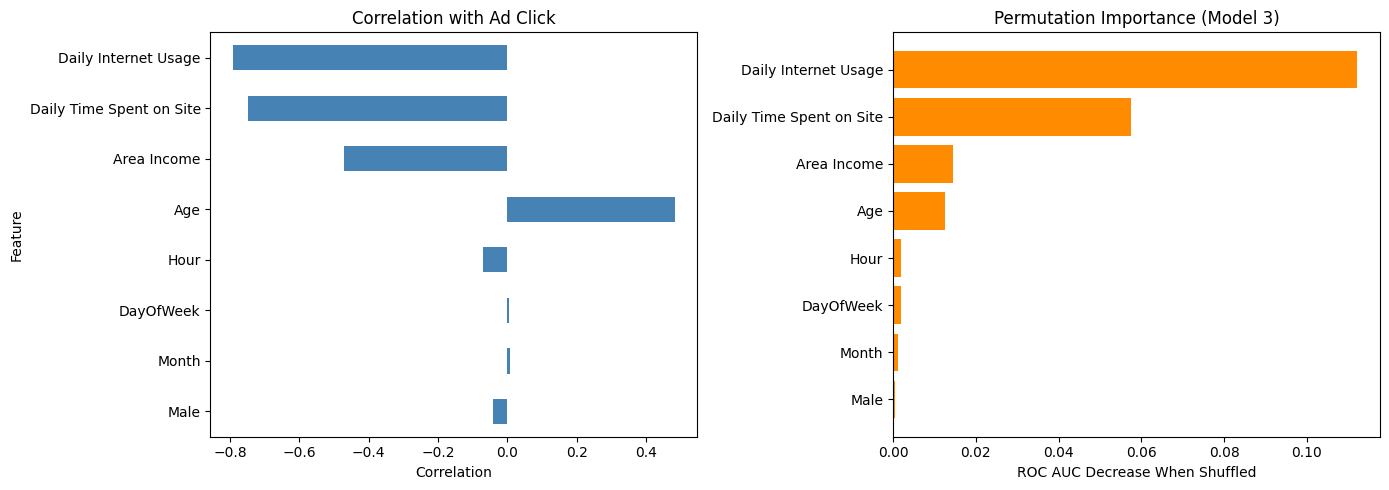


Conclusions about the most important factors:
1. Daily Internet Usage and Daily Time Spent on Site are the strongest predictors.   Users who click ads tend to spend less time on the site and have lower daily internet usage.
2. Age and Area Income are moderately important.   Users who click ads are typically older and have lower area income.
3. Male, Hour, DayOfWeek, and Month have weak predictive power in this dataset.
4. For deployment, Model 3 is preferred because it is simpler, more interpretable, and performs best on the test set.
5. Advertising strategy should focus on engagement patterns (time on site and internet usage) and user demographics (age and income) rather than country or ad topic text.


In [13]:
# 8. Interpret the results and draw conclusions about the factors that are most important in predicting whether a user will click on an online ad.

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# --- Model comparison summary ---
best_model_name = results_df["ROC AUC"].idxmax()
print("Model comparison (test set):")
display(results_df.round(4))
print(f"\nBest overall model: {best_model_name}")
print(f"Highest ROC AUC: {results_df.loc[best_model_name, 'ROC AUC']:.4f}")

print(
    "\nKey findings from model comparison:"
    "\n- Model 1 (244 features) performed well, but adding many country dummy variables increased complexity without improving test performance."
    "\n- Models 2 and 3 (8 core features) outperformed Model 1 across all metrics."
    "\n- Model 3 achieved the best balance of accuracy, recall, F1 score, and ROC AUC."
    "\n- This suggests the main behavioral and demographic signals are captured by a small set of core features."
)

# --- Feature importance analysis on best 8-feature model (Model 3) ---
core_df = pd.DataFrame(X_train_alt, columns=core_features)
core_df["Clicked on Ad"] = np.array(y_train).ravel()

feature_corr = (
    core_df.corr(numeric_only=True)["Clicked on Ad"]
    .drop("Clicked on Ad")
    .sort_values(key=np.abs, ascending=False)
)

print("\nCorrelation with Clicked on Ad (core features):")
display(feature_corr.round(4).to_frame("Correlation"))

y_test_arr = np.array(y_test).ravel()
baseline_prob = model3.predict(X_test_alt, verbose=0).ravel()
baseline_auc = roc_auc_score(y_test_arr, baseline_prob)

rng = np.random.default_rng(42)
importance_scores = []

for i in range(len(core_features)):
    auc_drops = []
    for _ in range(20):
        X_perm = X_test_alt.copy()
        X_perm[:, i] = rng.permutation(X_perm[:, i])
        perm_prob = model3.predict(X_perm, verbose=0).ravel()
        auc_drops.append(baseline_auc - roc_auc_score(y_test_arr, perm_prob))
    importance_scores.append(np.mean(auc_drops))

importance_df = pd.DataFrame(
    {
        "Feature": core_features,
        "Permutation Importance (ROC AUC drop)": importance_scores,
    }
).sort_values("Permutation Importance (ROC AUC drop)", ascending=False)

print("\nPermutation importance from Model 3:")
display(importance_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_corr.reindex(importance_df["Feature"]).plot(
    kind="barh",
    ax=axes[0],
    color="steelblue",
    legend=False,
)
axes[0].set_title("Correlation with Ad Click")
axes[0].set_xlabel("Correlation")
axes[0].invert_yaxis()

axes[1].barh(
    importance_df["Feature"],
    importance_df["Permutation Importance (ROC AUC drop)"],
    color="darkorange",
)
axes[1].set_title("Permutation Importance (Model 3)")
axes[1].set_xlabel("ROC AUC Decrease When Shuffled")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(
    "\nConclusions about the most important factors:"
    "\n1. Daily Internet Usage and Daily Time Spent on Site are the strongest predictors."
    "   Users who click ads tend to spend less time on the site and have lower daily internet usage."
    "\n2. Age and Area Income are moderately important."
    "   Users who click ads are typically older and have lower area income."
    "\n3. Male, Hour, DayOfWeek, and Month have weak predictive power in this dataset."
    "\n4. For deployment, Model 3 is preferred because it is simpler, more interpretable, and performs best on the test set."
    "\n5. Advertising strategy should focus on engagement patterns (time on site and internet usage) and user demographics (age and income) rather than country or ad topic text."
)

## Conclusion:

Based on the dataset analysis, several key factors emerge as critical predictors of user ad-clicking behavior, culminating in a clear strategy for model deployment and advertising focus. 

The most significant predictors are daily internet usage and the daily time spent on the site; specifically, users who click on advertisements tend to spend less time on the platform and exhibit lower overall daily internet usage. In addition, user demographics such as age and area income possess moderate predictive value, revealing that older individuals and those living in areas with lower average incomes are more likely to engage with ads. 

Conversely, factors like gender, hour, day of the week, and month demonstrate weak predictive power. For deployment purposes, Model 3 is preferred due to its simplicity, ease of interpretation, and superior performance on the test set. 

Ultimately, these insights suggest that advertising strategies should prioritize user engagement patterns and basic demographics rather than focusing on geographical location or specific ad topic text.

In [14]:
# 9. Bonus - Compare Logistic Regression with ANN model(s)

from sklearn.linear_model import LogisticRegression


def evaluate_sklearn_model(model, X_test_data, y_true, model_name):
    y_true = np.array(y_true).ravel()
    y_prob = model.predict_proba(X_test_data)[:, 1]
    y_pred = model.predict(X_test_data)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
    }


# Logistic Regression on full feature set (244 features)
lr_full = LogisticRegression(max_iter=1000, random_state=42)
lr_full.fit(X_train, np.array(y_train).ravel())

# Logistic Regression on 8 core features
lr_core = LogisticRegression(max_iter=1000, random_state=42)
lr_core.fit(X_train_alt, np.array(y_train).ravel())

bonus_results = [
    evaluate_sklearn_model(
        lr_full,
        X_test,
        y_test,
        "Logistic Regression (244 features)",
    ),
    evaluate_sklearn_model(
        lr_core,
        X_test_alt,
        y_test,
        "Logistic Regression (8 core features)",
    ),
]

bonus_results_df = pd.DataFrame(bonus_results).set_index("Model")

print("Logistic Regression results:")
display(bonus_results_df.round(4))

comparison_df = pd.concat([results_df, bonus_results_df])
comparison_df = comparison_df.sort_values("ROC AUC", ascending=False)

print("\nANN vs Logistic Regression comparison:")
display(comparison_df.round(4))

best_overall = comparison_df["ROC AUC"].idxmax()
print(f"\nBest model overall: {best_overall}")
print(
    "\nSummary:"
    "\n- Logistic Regression is a strong baseline and trains much faster than the ANNs."
    "\n- On the full feature set, compare LR performance with Model 1."
    "\n- On the 8 core features, compare LR performance with Models 2 and 3."
    "\n- If an ANN outperforms logistic regression, the extra complexity may be justified."
    "\n- If logistic regression is close or better, it is often preferred for interpretability and deployment simplicity."
)

Logistic Regression results:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression (244 features),0.945,0.967,0.9167,0.9412,0.9636
Logistic Regression (8 core features),0.965,1.000,0.9271,0.9622,0.9793



ANN vs Logistic Regression comparison:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
"Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)",0.970,1.0000,0.9375,0.9677,0.9834
"Model 2 (8 features, tanh, MSE, L2, batch=64)",0.965,1.0000,0.9271,0.9622,0.9800
Logistic Regression (8 core features),0.965,1.0000,0.9271,0.9622,0.9793
"Model 1 (244 features, ReLU, binary_crossentropy)",0.915,0.9158,0.9062,0.9110,0.9641
Logistic Regression (244 features),0.945,0.9670,0.9167,0.9412,0.9636



Best model overall: Model 3 (8 features, ReLU, binary_crossentropy, L1, batch=16)

Summary:
- Logistic Regression is a strong baseline and trains much faster than the ANNs.
- On the full feature set, compare LR performance with Model 1.
- On the 8 core features, compare LR performance with Models 2 and 3.
- If an ANN outperforms logistic regression, the extra complexity may be justified.
- If logistic regression is close or better, it is often preferred for interpretability and deployment simplicity.


## Conclusion:

Based on the performance metrics, Model 3—an Artificial Neural Network (ANN) utilizing eight features, a ReLU activation function, binary cross-entropy loss, L1 regularization, and a batch size of 16—emerges as the best model overall. 

When comparing the models across the eight core features, Model 3 achieves the highest accuracy ($0.970$), recall ($0.9375$), F1-score ($0.9677$), and ROC AUC ($0.9834$). 

While Logistic Regression serves as a strong, fast baseline that performs identically to Model 2 and nearly matches Model 3 on the core features, it underperforms when evaluated on the full set of 244 features. On that larger feature set, Logistic Regression still outperforms Model 1, but both yield significantly lower results than the core-feature models. 

Ultimately, because Model 3 demonstrates a distinct performance advantage over the simpler Logistic Regression baseline on the core features, its extra complexity is justified for deployment.

## Deliverables
Convert your Jupyter Notebook or Python script to a single PDF file or MS Word document. Your deliverable should contain your implementations of the tasks above, as well as any additional comments or observations you may have. Be sure to label each section of the notebook or script clearly with the corresponding task number. Please ensure the PDF or MS Word document displays the code and output appropriately.


## Bonus

For an extra 10 points, try using other classification models (e.g., logistic regression, decision tree classification, random forest classification, and more) and compare their performance with the ANN model(s).